In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
import sys
import matplotlib.pyplot as plt

PDM_DIR = os.environ.get('PDM_DIR', '../../../PDM')
sys.path.append(f'{PDM_DIR}/src')

import verbatim_eval.controlled_expr as _ce
import verbatim_eval.rouge_ttr as _rt
import verbatim_eval.utils as _ut
sys.modules['controlled_expr'] = _ce  # needed for pickle deserialization
sys.modules['rouge_ttr'] = _rt
sys.modules['utils'] = _ut

sys.path.insert(0, '../..')
from attn_bench.plotting import model_registry
from attn_bench.plotting.data_loading import load_mem_results_scores_grid
from attn_bench.plotting.heatmap import plot_heatmap_per_model

# Suffix boundaries


One generation run per (offset, prefix), sliced into every reachable suffix boundary.
Each heatmap: columns = suffix boundary, rows = repetition, single model (`full-scf1`
here), offset=0, prefix=500.

In [5]:
RESULTS_BASE = model_registry.MEM_RESULTS_DIR

OFFSET = 0
PREFIX = 500
SUFFIXES = [25, 50, 75, 100, 150, 250, 500, 750, 1000]  # reachable boundaries on store for this (offset, prefix)
MODEL = 'full-scf1'

results_grid = load_mem_results_scores_grid([OFFSET], [PREFIX], SUFFIXES, models=[MODEL], results_base=RESULTS_BASE)

### Rouge-L across suffix boundaries


In [ ]:
plot_heatmap_per_model(results_grid, metric='Rouge-L', model=MODEL, columns='suffix', values=SUFFIXES,
                   fixed_offset=OFFSET, fixed_prefix=PREFIX, )

### (n, p)-discoverable extraction across suffix boundaries

Hayes et al. 2025 -- fraction of samples with `1-(1-p_z)^n >= p`. `N_P_COMBOS` is a plain
list, add/remove pairs to try other values.

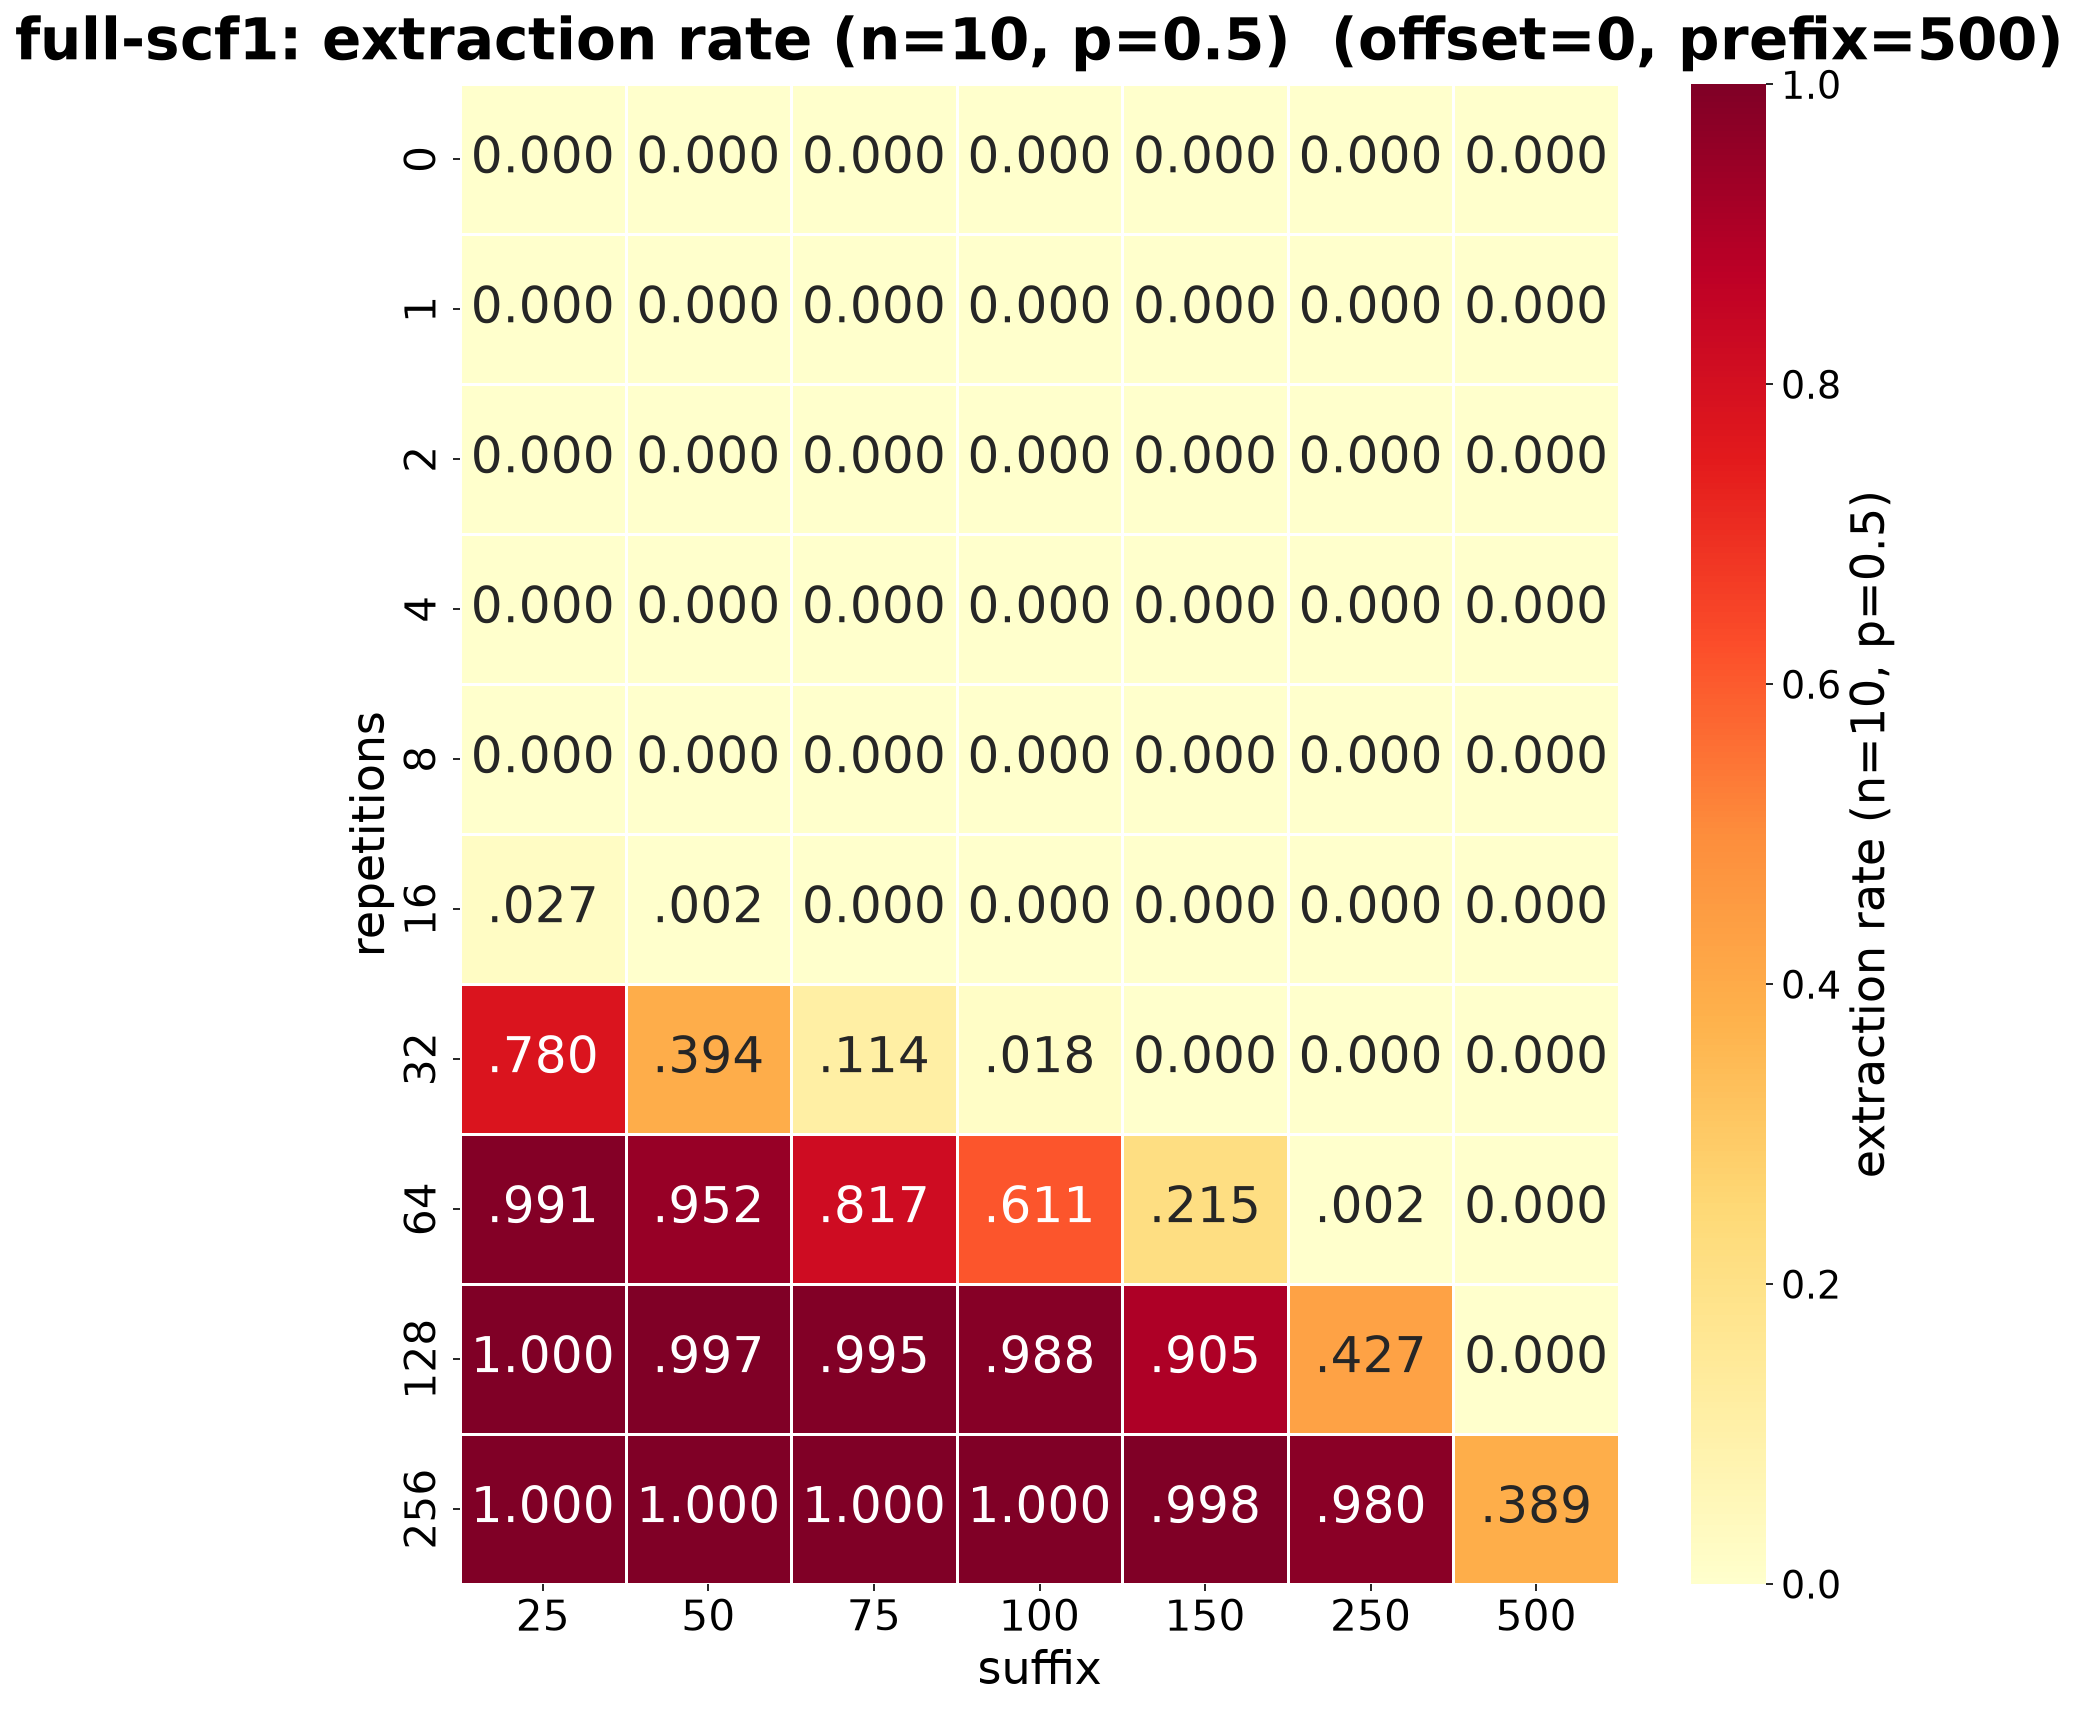

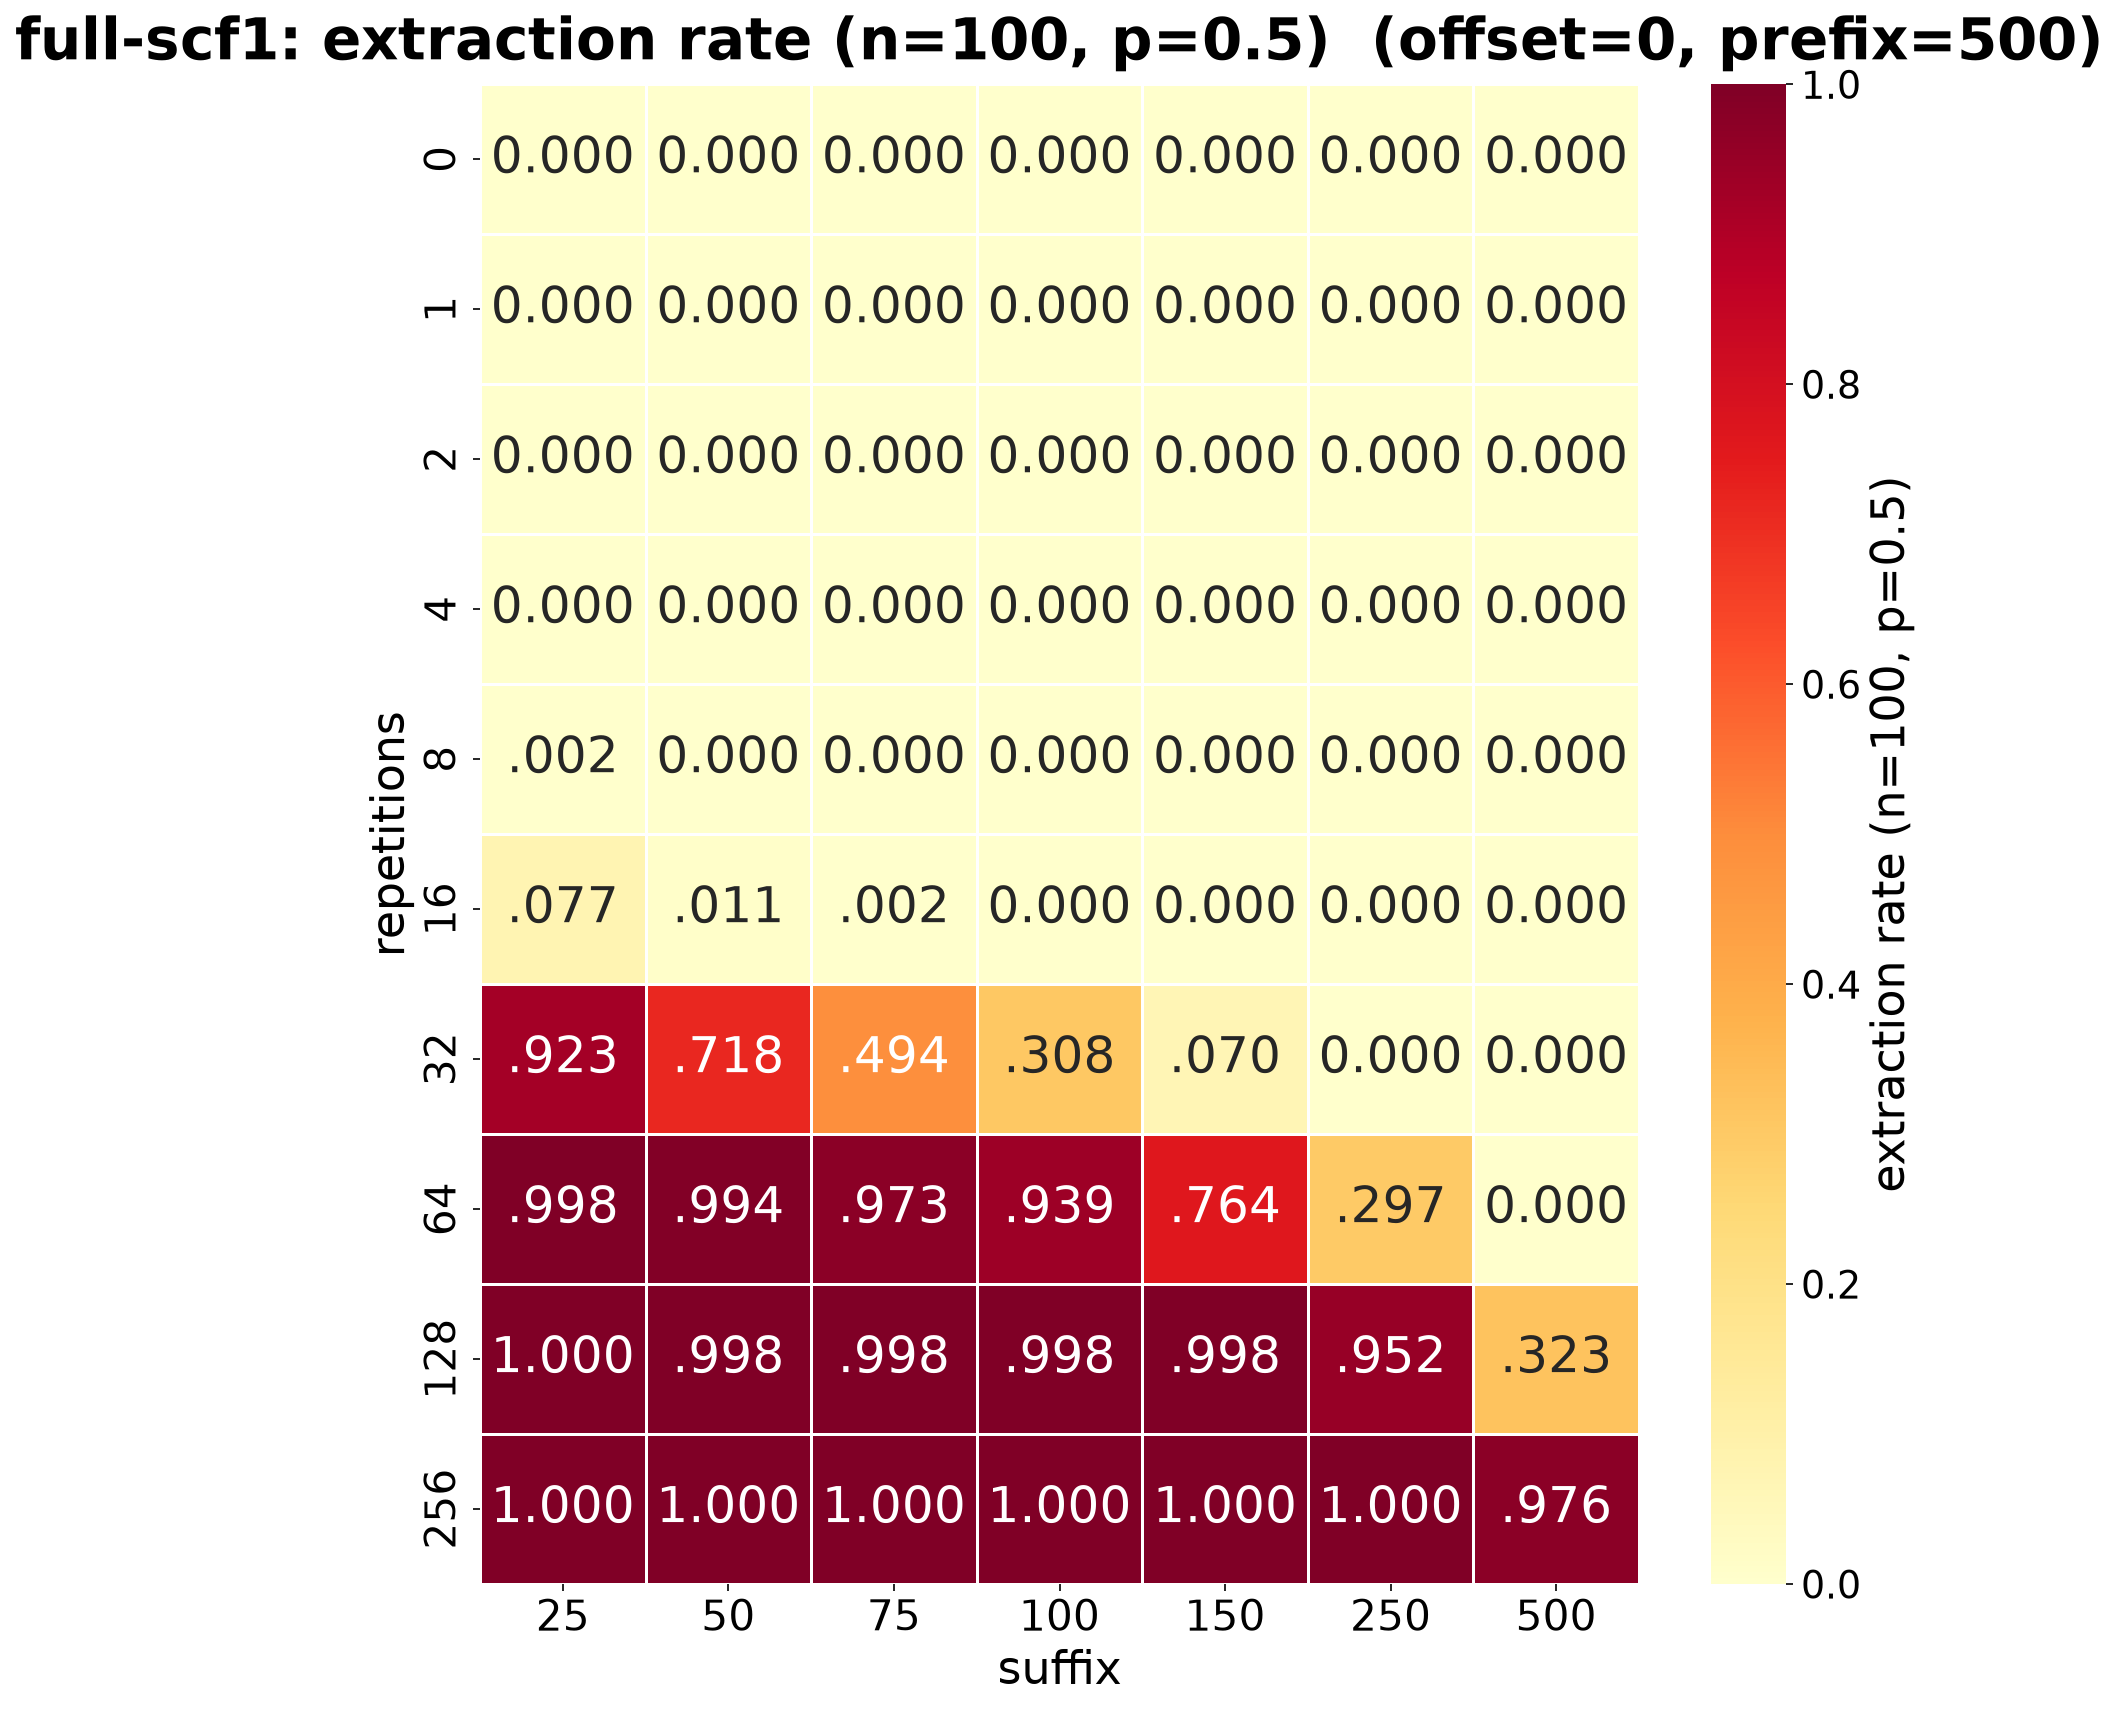

In [7]:
N_P_COMBOS = [(10, 0.5), (100, 0.5)]  # Hayes et al. 2025, Fig. 6 style

for n, p in N_P_COMBOS:
    plot_heatmap_per_model(results_grid, metric='hayes', n=n, p=p, model=MODEL, columns='suffix', values=SUFFIXES, fixed_offset=OFFSET, fixed_prefix=PREFIX)